In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

<Axes: title={'center': 'temp anual'}>

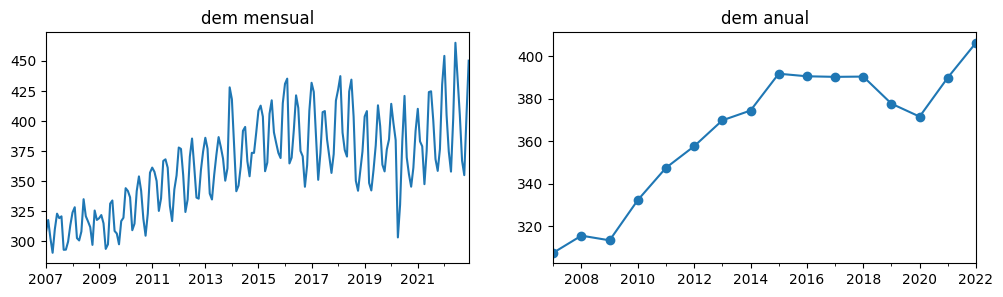

<Figure size 200x200 with 0 Axes>

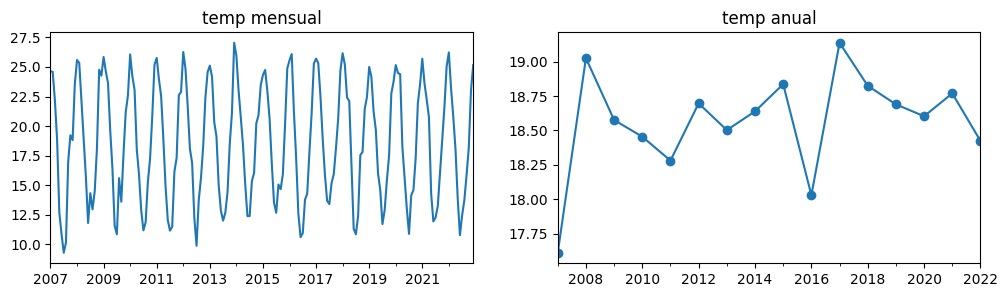

<Figure size 200x200 with 0 Axes>

In [3]:
# serie emi temp
dft=pd.read_csv('temp-arg.txt', sep=';', header=None, names=['year', 'month', 'day', 'value'])
temp=dft.set_index(pd.to_datetime(dft[['year', 'month', 'day']]) )['value']
# serie emi demanda
dfd = pd.read_csv('arg-dem.txt', sep=';', header=None, names=['year', 'month', 'day', 'value'])
dem=dfd.set_index(pd.to_datetime(dfd[['year', 'month', 'day']]))['value']
# muestra
fig, ax = plt.subplots(1,2, figsize=(12,3))
dem.resample('ME').mean().plot(style='-',ax=ax[0],title='dem mensual')
plt.figure(figsize=(2,2)) # (otra figura)
dem.resample('YE').mean().plot(style='-o',ax=ax[1],title='dem anual')
fig, ax = plt.subplots(1,2, figsize=(12,3))
temp.resample('ME').mean().plot(style='-',ax=ax[0],title='temp mensual')
plt.figure(figsize=(2,2)) # (otra figura)
temp.resample('YE').mean().plot(style='-o',ax=ax[1],title='temp anual')



Empiezo ajustando un modelo sencillo de la demanda en función de los índices hdd y cdd:

$$demand(t) = a_0 + a_1 \cdot t + a_2 \cdot hdd(t) + a_3 \cdot cdd(t) $$ <!-- + \sum_{i=4}^{10} a_i \cdot d_i(t)$$ -->

Son 4 parámetros, con lo cual **X** tiene 4 columnas y **n** filas (una fila por día):

$$\mathbf{X} = \begin{bmatrix} 1 & 1 & hdd_1 & cdd_1 \\ 1 & 2 & hdd_2 & cdd_2 \\ \vdots & \vdots & \vdots & \vdots \\ 1 & n & hdd_n & cdd_n \end{bmatrix} \qquad \boldsymbol{\beta} = \begin{bmatrix} a_0 \\ a_1 \\ a_2 \\ a_3 \end{bmatrix} \qquad \mathbf{y} = \begin{bmatrix} dem_1 \\ dem_2 \\ \vdots \\ dem_n \end{bmatrix}$$

$$\hat{\boldsymbol{\beta}} = \arg\min_{\boldsymbol{\beta}} \| \mathbf{y} - \mathbf{X}\boldsymbol{\beta} \|^2$$

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

Usamos `np.linalg.solve` en lugar de invertir explícitamente — es más estable numéricamente.


In [4]:
# preparo dataframes que necesito
T_base_hdd = 15.5
T_base_cdd = 22.0

df = pd.DataFrame()
df['dem'] = dem
df['temp'] = temp 
df['hdd'] = (T_base_hdd - temp).clip(lower=0)
df['cdd'] = (temp - T_base_cdd).clip(lower=0)
df['t'] = np.arange(len(df))
df['cero'] = np.ones(len(df))

#recorto el período que voy a usar
df = df.loc[(df.index.year > 2016) & (df.index.year < 2020)]

467.23,	-0.02,	0.99
441.48,	-0.02,	12.42,	15.63
441.48,	-0.02,	12.42,	15.63
443.91,	-0.02,	11.96,	15.03,	9.42,	15.67,	18.28,	15.21,	-16.60,	-44.35


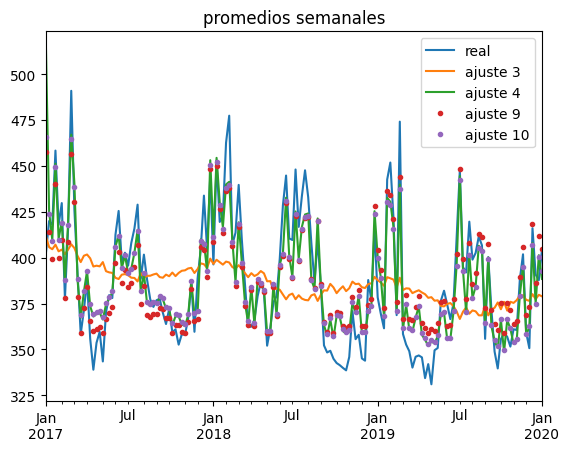

In [5]:
# ajusto una forma más sencilla todavía
X = df[['cero','t','temp']].values
y = df['dem'].values
beta = np.linalg.solve(X.T @ X, X.T @ y)
df['dem3']=X@beta
print(',\t'.join(f"{x:.2f}" for x in beta))

# el modelo de 4 parámetros
X = df[['cero','t', 'hdd', 'cdd']].values
y = df['dem'].values
beta = np.linalg.solve(X.T @ X, X.T @ y)
df['dem4']=X@beta
print(',\t'.join(f"{x:.2f}" for x in beta))

# el modelo de 9 parámetros (sin la lineal)
dummies = pd.get_dummies(df.index.dayofweek, prefix='dow', drop_first=True)
dummies.set_index(df.index, inplace = True)
X = np.concat([
    df[['cero', 'hdd', 'cdd']],
    dummies.values
], axis=1)
y = df['dem'].values
# print(X.shape, y.shape)
beta9 = np.linalg.solve(X.T @ X, X.T @ y)
df['dem9']=X@beta9
print(',\t'.join(f"{x:.2f}" for x in beta))


# el modelo de 10 parámetros
dummies = pd.get_dummies(df.index.dayofweek, prefix='dow', drop_first=True)
dummies.set_index(df.index, inplace = True)
X = np.concat([
    df[['cero', 't', 'hdd', 'cdd']],
    dummies.values
], axis=1)
y = df['dem'].values
# print(X.shape, y.shape)
beta = np.linalg.solve(X.T @ X, X.T @ y)
df['dem10']=X@beta
print(',\t'.join(f"{x:.2f}" for x in beta))


df['dem'].resample('W').mean().plot(label = 'real')
df['dem3'].resample('W').mean().plot(label = 'ajuste 3')
df['dem4'].resample('W').mean().plot(label = 'ajuste 4')
df['dem9'].resample('W').mean().plot(style = '.',label = 'ajuste 9')

df['dem10'].resample('W').mean().plot(style = '.',label = 'ajuste 10')
plt.title('promedios semanales')
plt.legend()

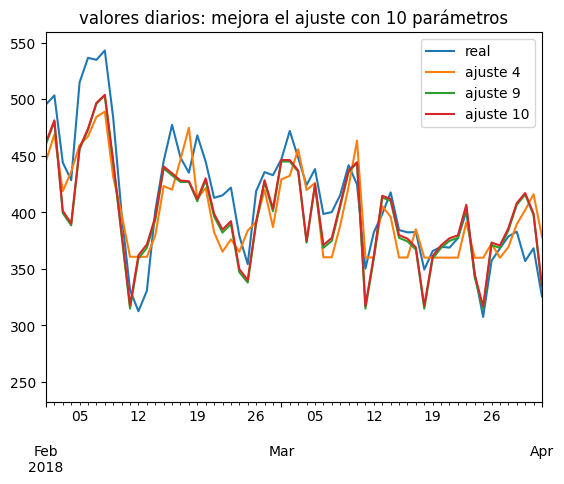

In [6]:

df['dem'].plot(label = 'real')
df['dem4'].plot(label = 'ajuste 4')
df['dem9'].plot(label = 'ajuste 9')

df['dem10'].plot(label = 'ajuste 10')

plt.xlim(left='20180201', right='20180401')
plt.title('valores diarios: mejora el ajuste con 10 parámetros')
plt.legend()

La fórmula correcta son 10 parámetros en total no tiene orden cero `a_0`. El orden cero queda contenido en el parámetro del día de la semana $a_i^{dow}$:

$$demand(t) = a_1 \cdot t + a_2 \cdot hdd(t) + a_3 \cdot cdd(t) + \sum_{i=4}^{10} a_i \cdot d_i(t)$$
donde 
$$d_i(t) = \begin{cases} 1 & \text{si } t \text{ cae el día } i \\ 0 & \text{si no} \end{cases}$$

Así por ejemplo la demanda para los días lunes será:
$$demanda_{lunes}(semana) = a_1 \cdot t + a_2 \cdot hdd(t) + a_3 \cdot cdd(t) + a^{lunes}$$

Otra manera de escribir la ecuación, para recuperar el background como se menciona en [], es

$$demand(t) =a_{lunes} + a_1 \cdot t + a_2 \cdot hdd(t) + a_3 \cdot cdd(t) + \sum_{i=4}^{9} a_i \cdot d_i(t)$$

Text(0, 0.5, 'demanda base relativa al lunes [GWhr]')

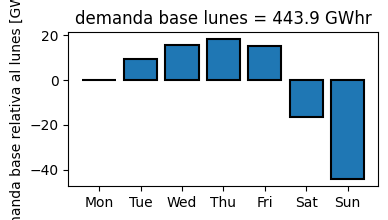

In [7]:
import calendar
dias = list(calendar.day_abbr)

plt.figure(figsize=(4,2))
plt.bar(x=dias,height=[0]+list(beta[-6:]),edgecolor='black', linewidth=1.5)
plt.title(f'demanda base lunes = {beta[0]:.1f} GWhr')
plt.ylabel('demanda base relativa al lunes [GWhr]')


<Axes: >

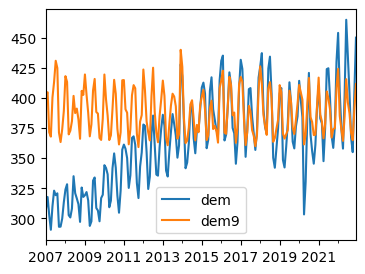

In [8]:
# vuelvo a definir df en todo el período
df=pd.DataFrame()
df['dem'] = dem
df['temp'] = temp 
df['hdd'] = (T_base_hdd - temp).clip(lower=0)
df['cdd'] = (temp - T_base_cdd).clip(lower=0)
# df['t'] = np.arange(len(df))
df['cero'] = np.ones(len(df))
dummies = pd.get_dummies(df.index.dayofweek, prefix='dow', drop_first=True)
dummies.set_index(df.index, inplace = True)
X = np.concat([
    df[['cero', 'hdd', 'cdd']],
    dummies.values
], axis=1)
plt.figure(figsize=(4,3))
df['dem9']=X@beta9
df[['dem','dem9']].resample('ME').mean().plot(ax=plt.gca())

In [9]:
df[['temp', 'dem', 'dem9']].to_csv('dem9.csv',float_format='%6.1f')

In [10]:
df['dem'].head()

2007-01-01    277.6
2007-01-02    325.4
2007-01-03    325.5
2007-01-04    334.0
2007-01-05    320.3
Name: dem, dtype: float64

<!-- ## Para `dem9` (sin término lineal):

$$demand(t) = a_0 + a_1 \cdot hdd(t) + a_2 \cdot cdd(t) + \sum_{i=3}^{8} a_i \cdot d_i(t)$$
donde 
$$d_i(t) = \begin{cases} 1 & \text{si } t \text{ cae el día } i \\ 0 & \text{si no} \end{cases}$$

Así por ejemplo la demanda para los días lunes será:
$$demanda_{lunes}(semana) = a_1 \cdot hdd(t) + a_2 \cdot cdd(t) + a^{lunes}$$

(los parámetros $a_i$ están en `beta9`)
ejemplo a continuación -->

<Axes: >

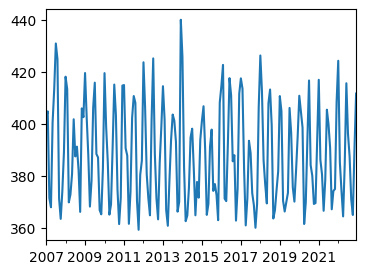

In [15]:
#conseguite los daatseries de temperatura

# luego:

df=pd.DataFrame()
df['temp'] = temp 
df['hdd'] = (T_base_hdd - temp).clip(lower=0)
df['cdd'] = (temp - T_base_cdd).clip(lower=0)
df['cero'] = np.ones(len(df))
dummies = pd.get_dummies(df.index.dayofweek, prefix='dow', drop_first=True)
X = np.concat([
    df[['cero', 'hdd', 'cdd']],
    dummies.values
], axis=1)
plt.figure(figsize=(4,3))
df['dem9']=X@beta9
df['dem9'].resample('ME').mean().plot(ax=plt.gca())